In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [9]:
data_dir = r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\data"
caravan_dir = r"Caravan1.4"
attributes_dir = "attributes"
timeseries_dir = r"timeseries"
data_type = "csv"
caravan_data = "hysets"

In [20]:
attrs_cara = pd.read_csv(os.path.join(data_dir, caravan_dir, attributes_dir, caravan_data, f"attributes_caravan_hysets.{data_type}"))
attrs_cara_names = attrs_cara.columns.to_list()
attrs_HA = pd.read_csv(os.path.join(data_dir, caravan_dir, attributes_dir, caravan_data, f"attributes_hydroatlas_hysets.{data_type}"))
attrs_HA_names = attrs_HA.columns.to_list()
attrs_geo = pd.read_csv(os.path.join(data_dir, caravan_dir, attributes_dir, caravan_data, f"attributes_other_hysets.{data_type}"))
attrs_geo_names = attrs_geo.columns.to_list()
attrs_geo.head()

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area
0,hysets_01010000,"St. John River at Ninemile Bridge, Maine",United States of America,46.700556,-69.715556,3467.387413
1,hysets_01010070,"Big Black River near Depot Mtn, Maine",United States of America,46.893889,-69.751667,475.007279
2,hysets_01010100,"Shields Br Big Black River nr Seven Islands, ME",United States of America,46.941625,-69.649475,404.295872
3,hysets_01010500,"St. John River at Dickey, Maine",United States of America,47.113056,-69.088056,6942.099132
4,hysets_01012515,CLAYTON STREAM AT OUTLET CLAYTON LAKE ME SITE 6,United States of America,46.730631,-68.771453,33.899206


In [24]:
us_gauges = attrs_geo[attrs_geo["country"]=="United States of America"].copy()
print(us_gauges.describe())
us_gauges.head()

          gauge_lat     gauge_lon           area
count  10683.000000  10683.000000   10683.000000
mean      39.370051    -96.587536    1459.838883
std        4.773722     16.214746    7174.943371
min       26.932558   -124.669121       0.724949
25%       35.953292   -111.193040      46.090467
50%       39.572661    -92.881005     180.560047
75%       42.700945    -82.799164     667.755581
max       48.998514    -67.266944  178592.039189


,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area
0,hysets_01010000,"St. John River at Ninemile Bridge, Maine",United States of America,46.700556,-69.715556,3467.387413
1,hysets_01010070,"Big Black River near Depot Mtn, Maine",United States of America,46.893889,-69.751667,475.007279
2,hysets_01010100,"Shields Br Big Black River nr Seven Islands, ME",United States of America,46.941625,-69.649475,404.295872
3,hysets_01010500,"St. John River at Dickey, Maine",United States of America,47.113056,-69.088056,6942.099132
4,hysets_01012515,CLAYTON STREAM AT OUTLET CLAYTON LAKE ME SITE 6,United States of America,46.730631,-68.771453,33.899206


In [27]:
us_gauge = us_gauges.iloc[0]

gauge_id                               hysets_01010000
gauge_name    St. John River at Ninemile Bridge, Maine
country                       United States of America
gauge_lat                                    46.700556
gauge_lon                                   -69.715556
area                                       3467.387413
Name: 0, dtype: object

In [40]:
check_gauge_id = "hysets_01010100"
data = pd.read_csv(os.path.join(data_dir, caravan_dir, timeseries_dir, data_type, caravan_data, f"{check_gauge_id}.{data_type}"))
print(data.describe())
data.head()

       snow_depth_water_equivalent_mean  surface_net_solar_radiation_mean  \
count                      26662.000000                      26662.000000   
mean                          59.378972                        118.904814   
std                           86.504529                         80.089028   
min                            0.000000                          2.300000   
25%                            0.000000                         48.270000   
50%                            1.960000                        101.705000   
75%                          106.555000                        180.717500   
max                          443.200000                        318.810000   

       surface_net_thermal_radiation_mean  surface_pressure_mean  \
count                        26662.000000           26662.000000   
mean                           -52.027711              97.511951   
std                             25.491579               0.816836   
min                           -112

,date,snow_depth_water_equivalent_mean,surface_net_solar_radiation_mean,surface_net_thermal_radiation_mean,surface_pressure_mean,temperature_2m_mean,dewpoint_temperature_2m_mean,u_component_of_wind_10m_mean,v_component_of_wind_10m_mean,volumetric_soil_water_layer_1_mean,...,dewpoint_temperature_2m_max,u_component_of_wind_10m_max,v_component_of_wind_10m_max,volumetric_soil_water_layer_1_max,volumetric_soil_water_layer_2_max,volumetric_soil_water_layer_3_max,volumetric_soil_water_layer_4_max,total_precipitation_sum,potential_evaporation_sum,streamflow
0,1951-01-01,31.17,41.81,-56.15,98.29,-11.24,-14.95,0.65,0.24,0.36,...,-11.72,1.26,2.04,0.36,0.36,0.37,0.42,0.01,2.56,NaN
1,1951-01-02,31.01,21.84,-24.63,97.83,-5.03,-8.21,1.32,1.77,0.36,...,-1.95,2.68,2.21,0.36,0.36,0.36,0.42,0.78,3.17,NaN
2,1951-01-03,29.87,12.28,-13.76,96.78,2.26,0.39,1.75,2.05,0.39,...,2.42,4.20,3.50,0.43,0.37,0.36,0.42,1.63,5.04,NaN
3,1951-01-04,32.77,5.31,-6.69,96.03,0.52,-0.39,0.78,0.58,0.43,...,2.11,5.47,2.61,0.44,0.40,0.36,0.42,15.40,2.61,NaN
4,1951-01-05,33.49,50.88,-75.40,97.78,-13.23,-17.40,2.95,0.26,0.41,...,-10.12,4.68,1.18,0.42,0.40,0.36,0.42,0.21,4.36,NaN


In [63]:
data[data['streamflow'].notna()]

,date,snow_depth_water_equivalent_mean,surface_net_solar_radiation_mean,surface_net_thermal_radiation_mean,surface_pressure_mean,temperature_2m_mean,dewpoint_temperature_2m_mean,u_component_of_wind_10m_mean,v_component_of_wind_10m_mean,volumetric_soil_water_layer_1_mean,...,dewpoint_temperature_2m_max,u_component_of_wind_10m_max,v_component_of_wind_10m_max,volumetric_soil_water_layer_1_max,volumetric_soil_water_layer_2_max,volumetric_soil_water_layer_3_max,volumetric_soil_water_layer_4_max,total_precipitation_sum,potential_evaporation_sum,streamflow
9405,1976-10-01,0.00,148.56,-74.51,97.91,7.18,1.75,-0.38,1.35,0.38,...,6.01,0.64,2.14,0.39,0.40,0.41,0.40,0.00,13.41,1.35
9406,1976-10-02,0.00,150.05,-73.14,97.74,11.52,7.78,0.99,0.86,0.38,...,10.99,1.94,1.73,0.38,0.39,0.40,0.40,0.00,12.53,1.08
9407,1976-10-03,0.00,157.28,-86.29,97.84,9.80,4.15,0.35,-1.59,0.37,...,8.95,2.06,-0.44,0.37,0.38,0.40,0.40,0.00,17.80,0.87
9408,1976-10-04,0.00,155.20,-84.68,98.55,7.41,0.92,-0.14,-0.21,0.36,...,4.26,0.91,2.17,0.37,0.38,0.40,0.40,0.00,15.17,0.73
9409,1976-10-05,0.00,153.48,-83.59,98.49,11.18,4.97,0.18,2.17,0.36,...,7.99,1.05,2.66,0.36,0.37,0.40,0.40,0.00,16.92,0.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10869,1980-10-04,1.77,14.52,-9.74,97.22,2.93,2.07,-0.90,-2.41,0.42,...,4.08,-0.00,-1.05,0.44,0.44,0.40,0.37,28.26,2.96,2.41
10870,1980-10-05,2.15,46.37,-16.93,98.37,5.03,3.47,-1.02,-0.08,0.41,...,5.32,-0.53,0.84,0.42,0.42,0.41,0.37,1.21,3.18,4.56
10871,1980-10-06,1.09,91.98,-44.48,98.45,6.21,4.04,-0.73,0.55,0.41,...,5.53,0.17,1.08,0.41,0.42,0.41,0.37,0.95,6.22,3.53
10872,1980-10-07,0.57,83.67,-45.05,97.81,6.03,4.17,-0.16,0.65,0.40,...,5.31,0.89,1.83,0.41,0.41,0.41,0.37,1.45,5.94,2.34


In [41]:
start_date = data.date.iloc[0]
end_date = data.date.iloc[-1]
nan_count = data.streamflow.isna().sum()
nan_fraction = nan_count/len(data.streamflow)


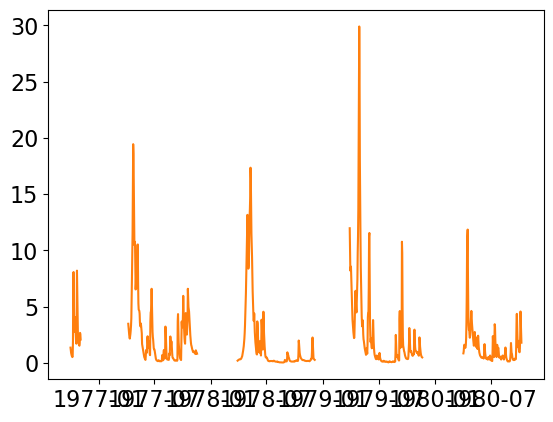

In [42]:
from datetime import datetime
plt.plot(pd.to_datetime(data.date), data.streamflow)

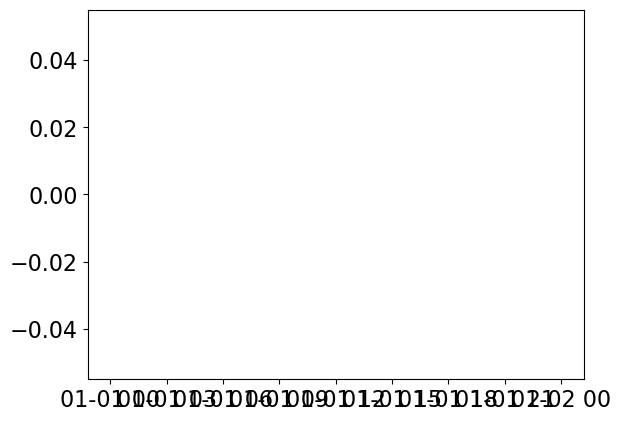

In [43]:
plt.plot(pd.to_datetime(data.date)[0:700], data.streamflow[0:700])

In [64]:
filename = r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\out\caravan_datacheck\hysets_summary.csv"
hysets_qa = pd.read_csv(filename)
hysets_qa["start_date"] = pd.to_datetime(hysets_qa["start_date"])
hysets_qa["end_date"] = pd.to_datetime(hysets_qa["end_date"])
hysets_qa.head()

,gauge_id,start_date,end_date,nan_count,nan_fraction
0,hysets_01010000,1951-01-01,2018-12-31,1825,0.068449
1,hysets_01010070,1983-10-01,2018-12-31,13786,0.517065
2,hysets_01010100,1976-10-01,1980-10-08,25724,0.964819
3,hysets_01010500,1951-01-01,2018-12-31,1825,0.068449
4,hysets_01012515,1982-07-15,1984-06-13,25962,0.973745


In [79]:
hysets_qa['duration_yr'] = (hysets_qa['end_date'] - hysets_qa['start_date']).dt.days / 365

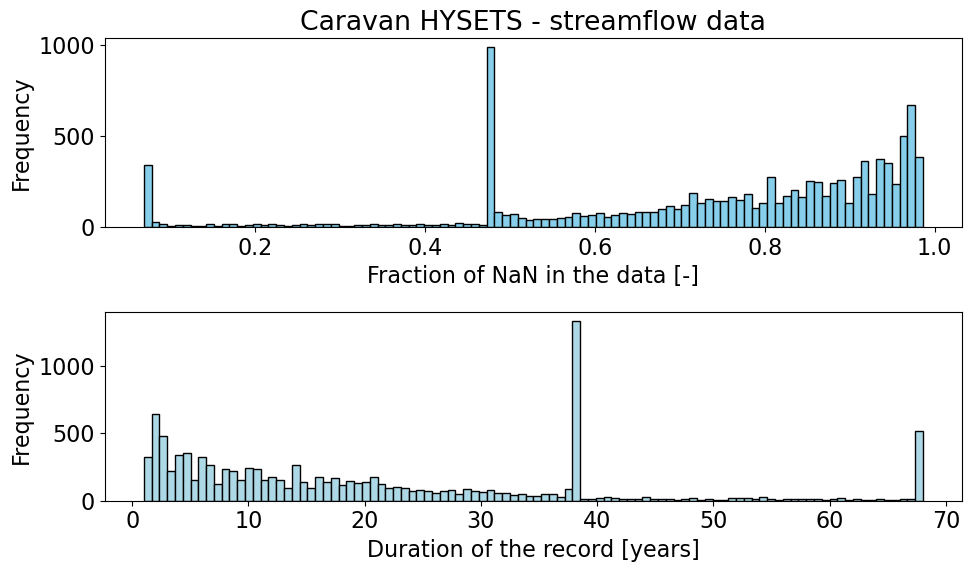

In [81]:
# Creating a 2x1 subplot layout
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Plotting the start year histogram
ax[0].hist(hysets_qa['nan_fraction'], bins=100, color='skyblue', edgecolor='black')
ax[0].set_title('Caravan HYSETS - streamflow data')
ax[0].set_xlabel('Fraction of NaN in the data [-]')
ax[0].set_ylabel('Frequency')

# Plotting the end year histogram
ax[1].hist(hysets_qa['duration_yr'], bins=100, color='lightblue', edgecolor='black')
ax[1].set_xlabel('Duration of the record [years]')
ax[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


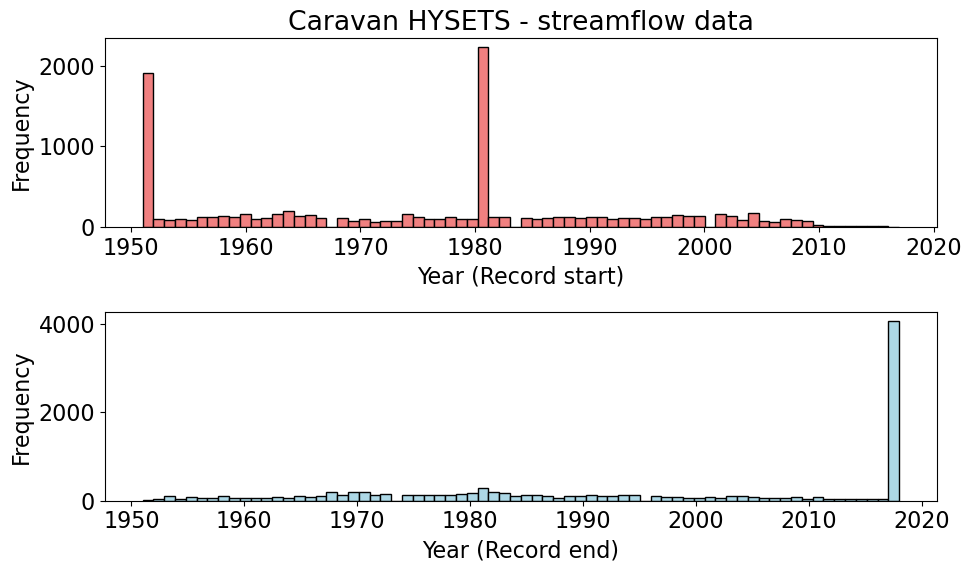

In [83]:
# Extracting the year from each start date
hysets_qa['start_year'] = hysets_qa['start_date'].dt.year
hysets_qa['end_year'] = hysets_qa['end_date'].dt.year


# Creating a 2x1 subplot layout
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Plotting the start year histogram
ax[0].hist(hysets_qa['start_year'], bins=70, color='lightcoral', edgecolor='black')
ax[0].set_title('Caravan HYSETS - streamflow data')
ax[0].set_xlabel('Year (Record start)')
ax[0].set_ylabel('Frequency')

# Plotting the end year histogram
ax[1].hist(hysets_qa['end_year'], bins=70, color='lightblue', edgecolor='black')
ax[1].set_xlabel('Year (Record end)')
ax[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

